Place cells model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats.qmc import Sobol, PoissonDisk
# for normal distribution pdf
from scipy.stats import norm

# from scipy.spatial import Voronoi

# for plotting circles
from matplotlib.collections import PatchCollection

from sklearn.metrics import pairwise_distances


from model import PlaceCellsModel

from ripser import Rips

from sklearn.manifold import Isomap

import umap

In [2]:
n_holes = 3

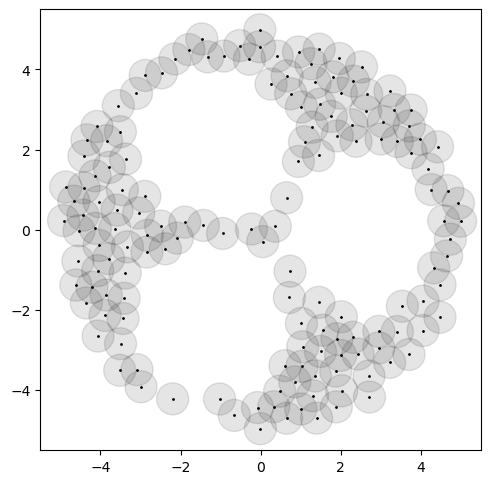

In [3]:
m = PlaceCellsModel(n_holes=n_holes, move_time_frac=0.99, n_cells=2000, cell_radius=0.04, sigma_activation=1.)

geo = m.geometry

traj = m.sample_Levy_walk(n_steps=128, min_step=0.3, max_step=5., exponent=1.5)

points = m.cells

fig, ax = plt.subplots(figsize=(5, 5))

_ = ax.scatter(points[:,0], points[:,1], c='black', s=1.)

circles = [plt.Circle((xi, yi), radius=0.04*10, fill=True, alpha=0.1, color='black') for xi, yi in points]

collection = PatchCollection(circles, match_original=True)
ax.add_collection(collection)

offset = 0.5

_ = ax.set(aspect='equal', 
           xlim=[-5-offset, 5+offset], ylim=[-5-offset, 5+offset])
          #,xlabel=r'$x_1$', ylabel=r'$x_2$',)

#_ = ax.plot(traj[:,0], traj[:,1], alpha=0.8, color='black')

fig.tight_layout()
#fig.savefig(f'h{n_holes}_arena.png',dpi=300)

In [4]:
m.n_cells

150

(3001, 150)


Text(0, 0.5, 'time')

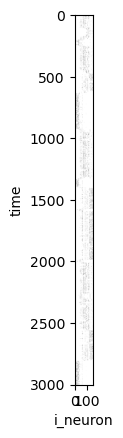

In [5]:
s = m.sample_signal(n_steps=3_000)
print(s.shape)

plt.imshow(1-s, cmap='gray')

plt.xlabel('i_neuron')
plt.ylabel('time')

In [6]:
# adding noise
s += np.random.normal(size=s.shape, loc=0, scale=0.01)

In [7]:
# normalizing
s = s/np.linalg.norm(s,axis=1)[:,np.newaxis]

# TDA

In [8]:
rips = Rips()
d = rips.fit_transform(s)

Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)


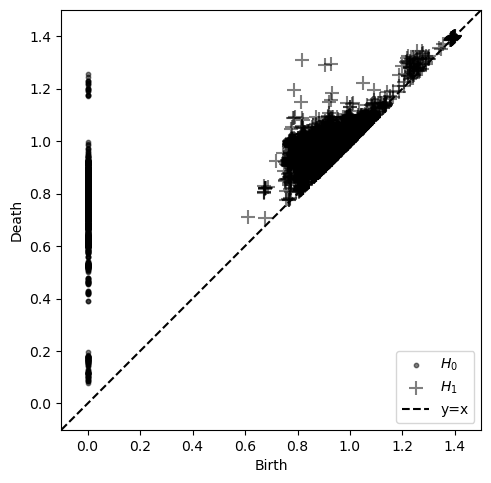

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(d[0][:,0],d[0][:,1],marker='o',s=10,alpha=0.5,color='black',label='$H_0$')
ax.scatter(d[1][:,0],d[1][:,1],marker='+',s=100,alpha=0.5,color='black',label='$H_1$')
amax = np.max(np.concatenate([d[0][np.isfinite(d[0])],d[1][np.isfinite(d[1])]]))

eps = 0.1
ax.set_xlim([-eps,amax+eps])
ax.set_ylim([-eps,amax+eps])
ax.set_aspect('equal')

ax.set_ylabel('Death')
ax.set_xlabel('Birth')

ax.plot(np.linspace(-eps,amax+eps,100),np.linspace(-eps,amax+eps,100),
        linestyle='--',color='black',label='y=x')

ax.legend(loc='lower right')

fig.tight_layout()
#fig.savefig(f'h{n_holes}_homology.png',dpi=300)

# UMAP

In [10]:
uemb = umap.UMAP(n_neighbors=5,min_dist=1.).fit_transform(s)

/Users/maxim/opt/anaconda3/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


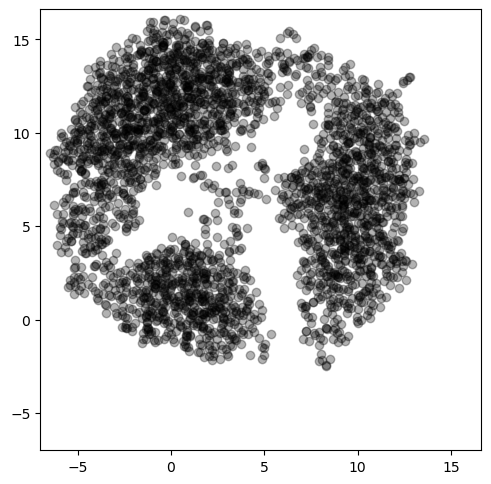

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(uemb[:,0],uemb[:,1],marker='o',color='black',alpha=0.3)

amax = np.max(uemb)
amin = np.min(uemb)

eps = 0.5
ax.set_xlim(amin-eps,amax+eps)
ax.set_ylim(amin-eps,amax+eps)

ax.set_aspect('equal')

fig.tight_layout()
fig.savefig(f'h{n_holes}_umap.png',dpi=300)

# Isomap

In [12]:
iso = Isomap()
iemb = iso.fit_transform(s)

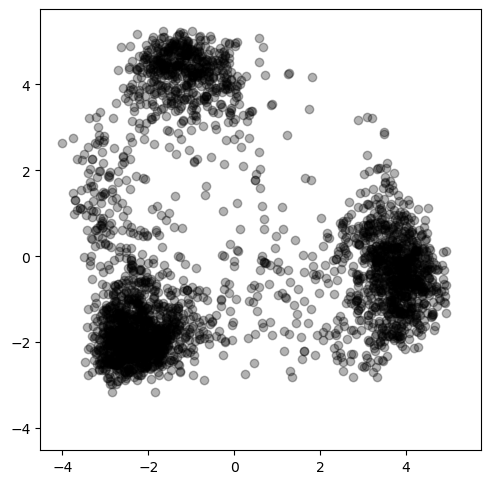

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(iemb[:,0],iemb[:,1],marker='o',color='black',alpha=0.3)

amax = np.max(iemb)
amin = np.min(iemb)

eps = 0.5
ax.set_xlim(amin-eps,amax+eps)
ax.set_ylim(amin-eps,amax+eps)

ax.set_aspect('equal')

fig.tight_layout()
#fig.savefig(f'h{n_holes}_isomap.png',dpi=300)